In [1]:
import torch
import os
import random
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from torchvision.utils import make_grid
#from modules_energy_score_xinwei import StoNet
from engression.models import StoNet, StoLayer
#from loss_func import energy_loss_two_sample
from engression.loss_func import energy_loss_two_sample
import argparse
import json
import xarray as xr
import torch.nn as nn
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

#from utils_cordex_v2 import get_data_cordex_v2
#from utils_cordex_v4 import get_data_cordex_v3
#from config import get_config
#from utils import *
#from models_cnn import cGenerator
import sys
#sys.path.append("..")

In [2]:
def torch_to_dataarray(x_tensor, coords_ds, lat_dim=32, lon_dim=32, name="variable", time_steps = None):
    """
    Convert a flattened 2D torch tensor to a 3D xarray.DataArray (lat, lon, time).

    Parameters:
    ----------
    x_tensor : torch.Tensor
        A 2D tensor of shape (time_steps, lat_dim * lon_dim), or a 1D tensor to be reshaped.
    lat_dim : int
        Number of latitude points.
    lon_dim : int
        Number of longitude points.
    coords_ds : xarray.Dataset
        Dataset containing 'lat', 'lon', and 'time' coordinates to assign.
    name : str, optional
        Name of the variable in the DataArray.

    Returns:
    -------
    xarray.DataArray
        The reshaped and labeled data as an xarray.DataArray.
    """
    # Step 1: Convert to NumPy
    data_np = x_tensor

    # Step 2: Determine time_steps and reshape
    if time_steps is None:
        time_steps = data_np.shape[0]
    data_np = data_np.reshape(time_steps, lat_dim, lon_dim)

    # Step 3: Transpose to (lat, lon, time)
    data_np = data_np.transpose(1, 2, 0)

    # Step 4: Create the DataArray
    da = xr.DataArray(
        data_np,
        dims=("lat", "lon", "time"),
        coords={
            "lat": coords_ds.lat,
            "lon": coords_ds.lon,
            "time": np.arange(time_steps)
        },
        name=name
    )

    return da

def plot_temperature_panel(ax, dataarray, vmax_shared, sample_nr=None, title=""):
    """
    Plot a single temperature panel on a given axis with Cartopy.

    Parameters:
    ----------
    ax : matplotlib.axes._subplots.AxesSubplot
        Axis on which to plot.
    dataarray : xarray.DataArray
        The temperature data to plot.
    title : str
        Title for the subplot.
    vmax_shared : float
        Symmetric max value for colormap scaling (vmin = -vmax).
    """
    levels = np.linspace(-5, 5, 11)

    p = dataarray.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=-vmax_shared,
        vmax=vmax_shared,
        levels=levels,
        add_colorbar=False
    )
    ax.set_title(title)
    ax.coastlines(resolution='110m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    #ax.gridlines(draw_labels=False)
    if sample_nr is not None:
        ax.text(
            x=0, y=0.5,                # left edge, center vertically
            s=sample_nr,          # your annotation text
            transform=ax.transAxes,   # interpret x/y in axis coordinates (0–1)
            rotation=90,              # rotate to align with y-axis
            va='center', ha='right',  # vertical/horizontal alignment
            fontsize=12
        )
    return p
    
def standardize_numpy(X):
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True)
    return (X - mean) / (std), mean, std
    
def visual_sample(model_enc, model_dec, model_pred, x, y): #, save_dir, to_img=True):
    model_enc.eval()
    model_dec.eval()
    model_pred.eval()
    with torch.no_grad():
        # gen = model(x).detach().cpu()#.view(x.shape[0], 1, 128, 128)
        rec1 = model_dec(model_enc(y)).detach().cpu()
        rec2 = model_dec(model_enc(y)).detach().cpu()
            
        gen1 = model_dec(model_pred(x)).detach().cpu()
        gen2 = model_dec(model_pred(x)).detach().cpu()
    #if to_img:
    #    rec1 = rec1.view(x.shape[0], 1, 32, 32)
    #    rec2 = rec2.view(x.shape[0], 1, 32, 32)
    #    gen1 = gen1.view(x.shape[0], 1, 32, 32)
    #    gen2 = gen2.view(x.shape[0], 1, 32, 32)
    #    y = y.view(y.shape[0], 1, 32, 32)
    # y = y.cpu().view(y.shape[0], 1, 128, 128)
    sample = torch.cat([y.cpu(), rec1, rec2, gen1, gen2])
    sample = torch.clamp(sample, torch.quantile(y, 0.005).item(), torch.quantile(y, 0.995).item())
    plt.matshow(make_grid(sample, nrow=y.shape[0]).permute(1, 2, 0)[:,:,0], cmap="Spectral_r"); plt.axis('off'); 
    #plt.savefig(save_dir, bbox_inches="tight", pad_inches=0, dpi=300); plt.close()
    # save_image(sample, save_dir, normalize=True, scale_each=True)
    plt.show()
    model_enc.train()
    model_dec.train()
    model_pred.train()



def data_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

def predictors_to_torch(ds, variable):
    temp_data = ds#[variable]
    data = temp_data.transpose('time', 'mode')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)

    
    # Flatten lat and lon together
    #time_steps, lat_dim, lon_dim = data_np.shape
    #data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    #data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [3]:
#if __name__ == '__main__':

#args = get_config()

random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#device = torch.device('cuda')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

#if args.cnn:
#    save_dir = f'results/eng/nm{args.n_models}/cnn_lat{args.latent_dim}'
#else:
#    save_dir = f"results/{args.method}/nm{args.n_models}_un/layer{args.num_layer}_hidden{args.hidden_dim}_noise{args.noise_dim}{args.save_name}/"

save_dir = "nn_joint_low_level_out/"
#make_folder(save_dir)
#write_config_to_file(args, save_dir)

device: cpu


In [4]:
#### load data

#train_loader, test_loader_in, test_loader_out = get_data_cordex_v3(args.n_models, variables = args.variables)
#print('#training batches:', len(train_loader))
#x_tr_eval, y_tr_eval = data2pair(next(iter(train_loader)), n=args.n_visual, device=device, keep_img=args.cnn, rank = args.rank)
#x_te_eval, y_te_eval = data2pair(next(iter(test_loader_in)), n=args.n_visual, device=device, keep_img=args.cnn, rank = args.rank)

# read contents from the settings.json file
settings_file_path = 'dpa_train_settings.json'

with open(settings_file_path, 'r') as file:
    settings = json.load(file)


# Create directories
#os.makedirs(output_dir, exist_ok=True)    

# Save to a new file for logging
with open(f"{save_dir}/used_settings.json", "w") as f:
    json.dump(settings, f, indent=4)

# load my temperature data
# Load your NetCDF file
ds = xr.open_dataset(settings['dataset_trefht'])

ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900)) #4769 * 80

# transform to torch tensors
x_tr = data_to_torch(ds_train, "TREFHT")
x_te = data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
ds_z500, _, _ = standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500) #predictors_to_torch(ds_z500, "pseudo_pcs")
print("z500 shape", z500.shape)
# scale Z500


z500_train = z500[:128000,:]#[:381520,:]
z500_test = z500[-64000:,:]

torch.Size([128000, 1024])
torch.Size([64000, 1024])
z500 shape (476900, 1000)
z500 shape torch.Size([476900, 1000])


In [13]:
x_tr.shape

torch.Size([128000, 1024])

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Dummy data
n, p, m = 100, 3, 2  # samples, features, outputs
X_train = np.random.randn(n, p)
Y_train = np.random.randn(n, m)

X_test = np.random.randn(30, p)
Y_test = np.random.randn(30, m)

# Fit model
model = LinearRegression()
model.fit(X_train, Y_train)

# Predict
Y_pred = model.predict(X_test)

# Adjusted R²
n_test = Y_test.shape[0]
for i in range(Y_test.shape[1]):
    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p - 1)
    print(f"Output {i+1}: Adjusted R² = {adj_r2:.4f}")


array(1)

In [45]:
## Linear model

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
import numpy as np


X = z500_train.numpy()[:,:10]
Y = x_tr[:,:].numpy()

print(X.shape, Y.shape)

# Fit model
model = LinearRegression()
model.fit(X, Y)

model_ridge = Ridge(alpha=0.001)       # alpha is the regularization strength (λ)
model_ridge.fit(X, Y)

# Predict
#Y_pred = model.predict(X)

(128000, 10) (128000, 1024)


Ridge(alpha=0.001)

In [24]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score


Y_test = x_te[:20000,:].numpy()
Y_pred = model.predict(z500_test[:20000,:10])
Y_pred_ridge = model_ridge.predict(z500_test[:20000,:10])

p =  5
r2_vals = []
rmse_vals = []
r2adj_vals=[]
n_test = Y_test.shape[0]
for i in range(Y_test.shape[1]):
    rmse = root_mean_squared_error(Y_test[:, i], Y_pred[:, i])
    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p - 1)
    rmse_vals.append(rmse)
    r2_vals.append(r2)
    r2adj_vals.append(adj_r2)
    #print(f"Output {i+1}: MSE = {mse:.4f}, R² = {r2:.4f}")



In [46]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

#def root_mean_squared_error(y_true, y_pred):
#    return np.sqrt(mean_squared_error(y_true, y_pred))

Y_test = x_te[:20000, :].numpy()
X_test = z500_test[:20000, :10]

Y_pred = model.predict(X_test)        # Linear Regression
Y_pred_ridge = model_ridge.predict(X_test)  # Ridge Regression

p = 10  # number of predictors
n_test = Y_test.shape[0]
d = Y_test.shape[1]  # number of output dimensions

# Initialize metric containers
metrics_linear = {"r2": [], "r2_adj": [], "rmse": []}
metrics_ridge = {"r2": [], "r2_adj": [], "rmse": []}

# Loop over output dimensions
for i in range(d):
    # Linear metrics
    r2_lin = r2_score(Y_test[:, i], Y_pred[:, i])
    rmse_lin = root_mean_squared_error(Y_test[:, i], Y_pred[:, i])
    adj_r2_lin = 1 - (1 - r2_lin) * (n_test - 1) / (n_test - p - 1)

    metrics_linear["r2"].append(r2_lin)
    metrics_linear["r2_adj"].append(adj_r2_lin)
    metrics_linear["rmse"].append(rmse_lin)

    # Ridge metrics
    r2_ridge = r2_score(Y_test[:, i], Y_pred_ridge[:, i])
    rmse_ridge = root_mean_squared_error(Y_test[:, i], Y_pred_ridge[:, i])
    adj_r2_ridge = 1 - (1 - r2_ridge) * (n_test - 1) / (n_test - p - 1)

    metrics_ridge["r2"].append(r2_ridge)
    metrics_ridge["r2_adj"].append(adj_r2_ridge)
    metrics_ridge["rmse"].append(rmse_ridge)


In [47]:
r2_map = torch_to_dataarray(np.array(metrics_linear["r2"]), coords_ds=ds_test, lat_dim=32, lon_dim=32, name="r2", time_steps = np.array(1))
#r2adj_map = torch_to_dataarray(np.array(r2adj_vals), coords_ds=ds_test, lat_dim=32, lon_dim=32, name="r2", time_steps = np.array(1))
rmse_map = torch_to_dataarray(np.array(metrics_linear["rmse"]), coords_ds=ds_test, lat_dim=32, lon_dim=32, name="mse", time_steps = np.array(1))

r2_map_ridge = torch_to_dataarray(np.array(metrics_ridge["r2"]), coords_ds=ds_test, lat_dim=32, lon_dim=32, name="r2", time_steps = np.array(1))
rmse_map_ridge = torch_to_dataarray(np.array(metrics_ridge["rmse"]), coords_ds=ds_test, lat_dim=32, lon_dim=32, name="mse", time_steps = np.array(1))

r2_map

<xarray.DataArray 'r2' (lat: 32, lon: 32, time: 1)> Size: 8kB
array([[[0.08137435],
        [0.11670053],
        [0.18790513],
        ...,
        [0.03652823],
        [0.02485728],
        [0.0159176 ]],

       [[0.10333759],
        [0.15161884],
        [0.21952653],
        ...,
        [0.04871213],
        [0.02767175],
        [0.02893662]],

       [[0.11832678],
        [0.18700826],
        [0.26538765],
        ...,
...
        ...,
        [0.46899092],
        [0.45638174],
        [0.4410432 ]],

       [[0.36227065],
        [0.36682433],
        [0.36356926],
        ...,
        [0.47047752],
        [0.45677871],
        [0.44634455]],

       [[0.38352817],
        [0.37800539],
        [0.37187183],
        ...,
        [0.46192569],
        [0.45497352],
        [0.44235396]]], shape=(32, 32, 1))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) int64 8B 0

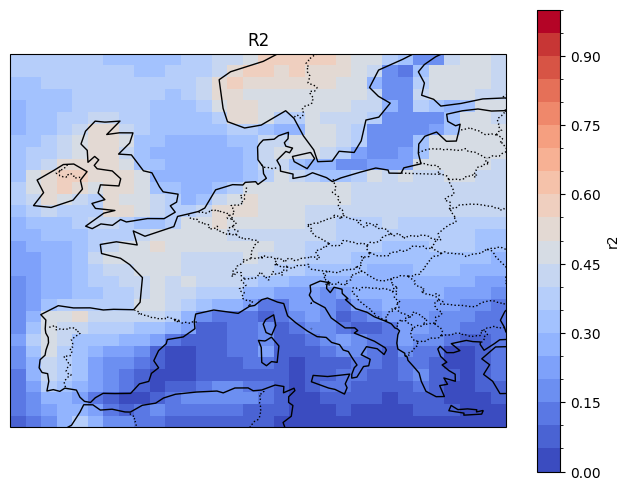

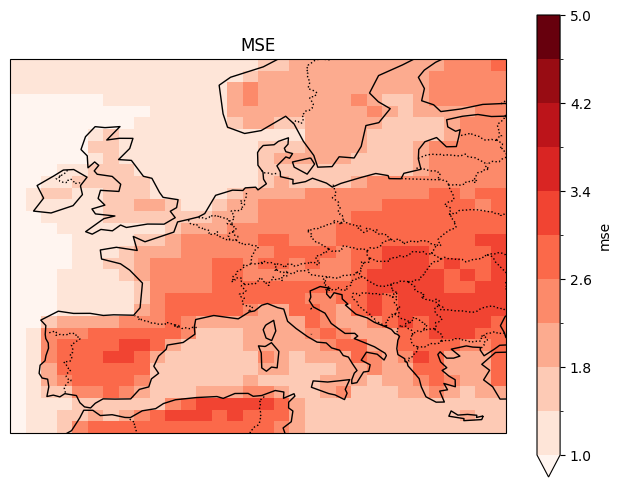

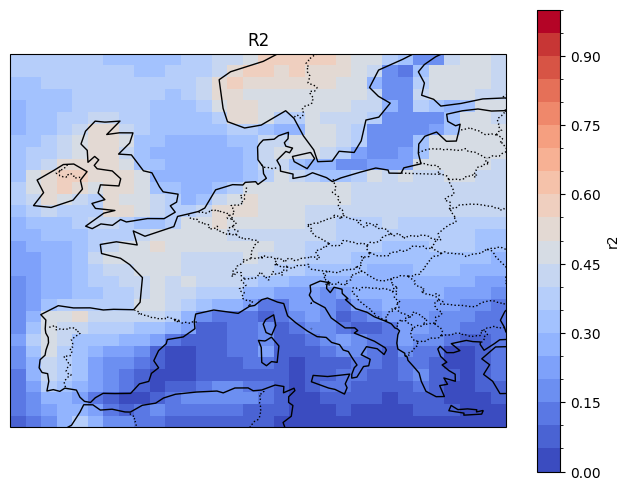

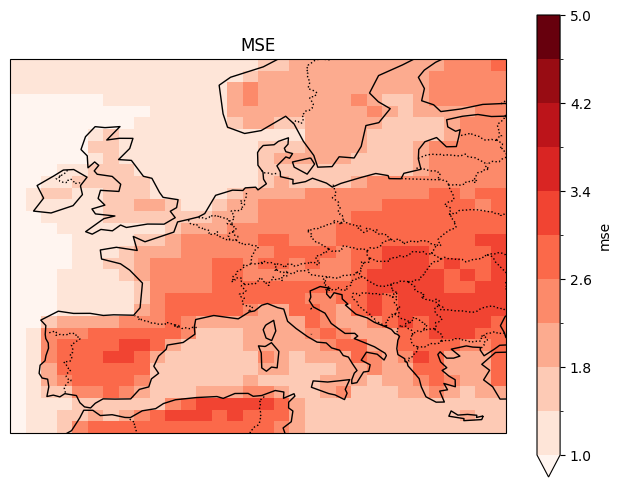

In [48]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Create a figure with one subplot using PlateCarree projection
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.linspace(0, 1, 21)
p = r2_map.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        #vmin=-vmax_shared,
        #vmax=vmax_shared,
        levels=levels,
        add_colorbar=True
    )
ax.set_title("R2")
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
#ax.gridlines(draw_labels=False)
plt.show()


################################################################################



fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.linspace(1, 5, 11)
p = rmse_map.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='Reds',
        #vmin=-vmax_shared,
        #vmax=vmax_shared,
        levels=levels,
        add_colorbar=True
    )
ax.set_title("MSE")
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
#ax.gridlines(draw_labels=False)
plt.show()

################################################################################
#################################################################################

# Create a figure with one subplot using PlateCarree projection
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.linspace(0, 1, 21)
p = r2_map_ridge.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        #vmin=-vmax_shared,
        #vmax=vmax_shared,
        levels=levels,
        add_colorbar=True
    )
ax.set_title("R2")
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
#ax.gridlines(draw_labels=False)
plt.show()


#################################################################################


fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.linspace(1, 5, 11)
p = rmse_map_ridge.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='Reds',
        #vmin=-vmax_shared,
        #vmax=vmax_shared,
        levels=levels,
        add_colorbar=True
    )
ax.set_title("MSE")
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
#ax.gridlines(draw_labels=False)
plt.show()
